In [ ]:
# ---- Imports ----
import kagglehub #install this before running the notebook to download the dataset locally
import os
import re
import ast
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import torch.nn.functional as F
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel, AutoModelForCausalLM

## Data exploration

#### Load the CommonsenseQA dataset

In [3]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("thedevastator/new-commonsenseqa-dataset-for-multiple-choice-qu")
print("Path:", path)

# List files inside the dataset directory & display train df 
print(f"Files available: {os.listdir(path)}\n")
df = pd.read_csv(f"{path}/train.csv")
df

# Validation --> Use as test 
df_val = pd.read_csv(f"{path}/validation.csv", index_col=0)
df_val.index.name = "answerKey"
df_val = df_val.reset_index()
print(f"Empty rows Val: {df_val['answerKey'].isnull().sum()}\n") #checked: is 0 
print(f"Quick check: Val split distribution\n{df_val['answerKey'].value_counts().to_dict()}\n")
#df_val

# Test 
df_test = pd.read_csv(f"{path}/test.csv", index_col=0)
df_test.index.name = "answerKey"
df_test = df_test.reset_index()
print(f"Empty rows Test: {df_test['answerKey'].isnull().sum()}") #checked: no rows contain answers (1140)
#df_test

df_all = pd.concat([df, df_val], ignore_index=True)
print(len(df), len(df_val), len(df_all))
df_all.head()

Path: C:\Users\Nour\.cache\kagglehub\datasets\thedevastator\new-commonsenseqa-dataset-for-multiple-choice-qu\versions\2
Files available: ['test.csv', 'train.csv', 'validation.csv']

Empty rows Val: 0

Quick check: Val split distribution
{'B': 255, 'D': 251, 'C': 241, 'A': 239, 'E': 235}

Empty rows Test: 1140
9741 1221 10962


,answerKey,question,choices
0,A,The sanctions against the school were a punish...,"{'label': array(['A', 'B', 'C', 'D', 'E'], dty..."
1,B,Sammy wanted to go to where the people were. ...,"{'label': array(['A', 'B', 'C', 'D', 'E'], dty..."
2,A,To locate a choker not located in a jewelry bo...,"{'label': array(['A', 'B', 'C', 'D', 'E'], dty..."
3,D,Google Maps and other highway and street GPS s...,"{'label': array(['A', 'B', 'C', 'D', 'E'], dty..."
4,C,"The fox walked from the city into the forest, ...","{'label': array(['A', 'B', 'C', 'D', 'E'], dty..."


#### Basic exploration 

In [4]:
print(f"Shape: {df_all.shape}")
print(f"Columns: {df_all.columns.tolist()}")
print(f"\nDtypes:\n{df_all.dtypes}")
print(f"\nFirst row:\n{df_all.iloc[0]}")

# Check for missing values 
print("\nMissing values")
print(df_all.isnull().sum())
print(f"Duplicate rows: {df_all.duplicated().sum()}")

Shape: (10962, 3)
Columns: ['answerKey', 'question', 'choices']

Dtypes:
answerKey    str
question     str
choices      str
dtype: object

First row:
answerKey                                                    A
question     The sanctions against the school were a punish...
choices      {'label': array(['A', 'B', 'C', 'D', 'E'], dty...
Name: 0, dtype: str

Missing values
answerKey    0
question     0
choices      0
dtype: int64
Duplicate rows: 0


#### Cleaning/Formatting

In [5]:
# Convert the raw string into a real Python object
print(f"Raw string (before applying parse_choices):\n{repr(df_all['choices'].iloc[0])}\n")

def parse_choices(raw):
    """
    Converts the stringified dict to a plain {label: text} dict
    """
    # Remove numpy array wrapper: array([...], dtype=object) ->  [...]
    cleaned = re.sub(r"array\((\[.*?\]),\s*dtype=object\)", r"\1", raw, flags=re.DOTALL)
    try:
        d = ast.literal_eval(cleaned) # So this string: {'label': array([...]), 'text': array([...])} becomes an actual dict with 2 numpy arrays inside
        return dict(zip(list(d["label"]), list(d["text"]))) #takes the 2 arrays (labels & texts), and pair them up into a clean, usable dict
    except Exception:
        return {}
 
df_all["choices_parsed"] = df_all["choices"].apply(parse_choices) #{'A': 'option1', 'B': 'option2', 'C': 'option3', ...}
df_all["num_choices"] = df_all["choices_parsed"].apply(len)
print(f"\nChoice counts per question:\n{df_all['num_choices'].value_counts()}")

# Flatten all choice texts across all rows into one flat list for length analysis
all_choice_texts = [text for c in df_all["choices_parsed"] for text in c.values()]

# Example of parse_choices applied 
sample = df_all["choices"].iloc[0]
print(f"\nResulting string (after applying parse_choices):\n{parse_choices(sample)}")


Raw string (before applying parse_choices):
"{'label': array(['A', 'B', 'C', 'D', 'E'], dtype=object), 'text': array(['ignore', 'enforce', 'authoritarian', 'yell at', 'avoid'],\n      dtype=object)}"


Choice counts per question:
num_choices
5    10962
Name: count, dtype: int64

Resulting string (after applying parse_choices):
{'A': 'ignore', 'B': 'enforce', 'C': 'authoritarian', 'D': 'yell at', 'E': 'avoid'}


In [6]:
# Cleaning checks 
print("\nCleaning checklist")
unparseable = (df_all["num_choices"] == 0).sum()
bad_keys = df_all.apply(lambda r: r["answerKey"] not in r["choices_parsed"], axis=1).sum()
no_question_mark = (~df_all["question"].str.strip().str.endswith("?")).sum()
 
print(f" Rows with unparseable choices: {unparseable}") 
print(f" Rows where answerKey is not in choices: {bad_keys}") #all correct answers are present in options 
print(f" Questions missing trailing '?': {no_question_mark}") #not all questions have a question mark 


Cleaning checklist
 Rows with unparseable choices: 0
 Rows where answerKey is not in choices: 0
 Questions missing trailing '?': 81


#### Feature engineering & Basic statistics 

In [7]:
# Feature Engineering: question level features 
df_all["q_starts_with"] = df_all["question"].str.split().str[0].str.lower()
df_all["q_len_chars"] = df_all["question"].str.len()
df_all["q_len_words"] = df_all["question"].str.split().str.len()
# Mean choice length: characters 
df_all["choice_len_mean"] = df_all["choices_parsed"].apply(
     lambda d: np.mean([len(t) for t in d.values()]) if d else np.nan)
# Mean choice length: words
df_all["choice_len_mean_words"] = df_all["choices_parsed"].apply(
    lambda d: np.mean([len(t.split()) for t in d.values()]) if d else np.nan)

# Basic statistics: q&a distributions 
print("\nAnswer key distribution")
print("-"*30)
order = sorted(df_all["answerKey"].dropna().unique())
counts = df_all["answerKey"].value_counts().reindex(order)
percentages = counts / counts.sum() * 100
summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)})
print(summary)

print("\nTop 10 question-opening words")
print("-"*30)
print(df_all["q_starts_with"].value_counts().head(10))

print("\nQuestion length (words)")
print("-"*30)
print(df_all["q_len_words"].describe())

print("\nQuestion length (characters)")
print("-"*30)
print(df_all["q_len_chars"].describe())

print("\nMean choice length (characters)")
print("-"*30)
print(df_all["choice_len_mean"].describe())

print("\nMean choice length (words)")
print("-"*30)
print(df_all["choice_len_mean_words"].describe())


Answer key distribution
------------------------------
           Count  Percentage
answerKey                   
A           2148       19.59
B           2228       20.32
C           2187       19.95
D           2236       20.40
E           2163       19.73

Top 10 question-opening words
------------------------------
q_starts_with
what     2392
where    2035
the      1410
if        742
when      321
a         311
he        285
john      226
why       211
james     203
Name: count, dtype: int64

Question length (words)
------------------------------
count    10962.000000
mean        13.233808
std          5.499896
min          3.000000
25%          9.000000
50%         12.000000
75%         16.000000
max         63.000000
Name: q_len_words, dtype: float64

Question length (characters)
------------------------------
count    10962.000000
mean        69.314450
std         29.340796
min         15.000000
25%         48.000000
50%         64.000000
75%         84.000000
max        376.000

#### Linguistic feature analysis 
These features proxy for question difficulty and potential model failure modes (factors likely to influence where confidence and correctness diverge).


- Question difficulty signal, proxied with negation: Questions with negation words require more reasoning 
steps and models are known to struggle with them. A predefined 
[negations word list](https://aclanthology.org/P17-1154.pdf) was used for detection.

- Lexical overlap between questions and choices: If a choice reuses words from the question, a model might pick it due to surface-level matching rather than reasoning --> would show up as high confidence on a wrong answer (shortcut behaviour).

- Distractor quality (choice length variation): If all choices are very similar, the task is harder and confidence scores should be lower. If one choice is obviously different, confidence might be high but for the wrong reason

In [8]:
# Flag questions containing negations (models often struggle with these)
df_all["has_negation"] = df_all["question"].str.contains(
    r"\b(no|not|never|neither|except|nobody|nothing|nowhere|seldom|scarcely|hardly|barely|cannot|least|without|n't)\b", 
    case=False, regex=True)

# Convert to percentages for easy interpretation 
negation_pct = df_all["has_negation"].value_counts(normalize=True) * 100
print(f"Contains negation: {negation_pct[True]:.1f}%  ({df_all['has_negation'].sum()} questions)")
print(f"No negation: {negation_pct[False]:.1f}%  ({(~df_all['has_negation']).sum()} questions)")
print("-"*30)


def tokenize(text):
    return set(re.findall(r"\b\w+\b", text.lower()))

def overlap(row):
    """
    Compute word overlap between the question and each answer choice.
    Returns: dict: mapping choice key -> number of shared tokens with the question
    """
    q_words = tokenize(row["question"])
    return {k: len(q_words & set(v.lower().split())) for k, v in row["choices_parsed"].items()}

# Compute overlap scores for each choice per question
df_all["q_choice_overlap"] = df_all.apply(overlap, axis=1)
# Extract overlap score for the correct answer
df_all["correct_overlap"] = df_all.apply(lambda r: r["q_choice_overlap"].get(r["answerKey"], 0), axis=1)
# Compute maximum overlap among all answer choices
df_all["max_overlap"] = df_all["q_choice_overlap"].apply(lambda d: max(d.values()))
# Check if correct answer has the highest overlap
df_all["correct_is_max_overlap"] = ((df_all["correct_overlap"] == df_all["max_overlap"]) &  
    (df_all["max_overlap"] > 0))

overlap_pct = df_all["correct_is_max_overlap"].mean() * 100
# If the correct answer consistently has the highest overlap, models may be use surface-level
# word matching rather than reasoning 
print(f"Correct answer has highest word overlap with question in: {overlap_pct:.1f}% of cases")
print(f"{'-> Potential shortcut risk' if overlap_pct > 50 else '-> Limited evidence of overlap bias'}")
print("-"*30)


# Measure how much answer choices vary in length within each question.
df_all["choice_text_lengths"] = df_all["choices_parsed"].apply(
    lambda d: [len(v) for v in d.values()])
# Compute standard deviation of choice lengths (per question)
df_all["choice_len_std"] = df_all["choice_text_lengths"].apply(np.std)
print(f"Mean std across questions: {df_all['choice_len_std'].mean():.2f} chars")
print(f"Median std: {df_all['choice_len_std'].median():.2f} chars")
print(f"Questions with high variance (std > 10): {(df_all['choice_len_std'] > 10).sum()}")

# High variance (std) suggests uneven distractors (varying a lot in length): one choice may stand out visually,
# which can artificially increase model confidence regardless of correctness

Contains negation: 7.4%  (806 questions)
No negation: 92.6%  (10156 questions)
------------------------------


C:\Users\Nour\AppData\Local\Temp\ipykernel_14432\3220471234.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_all["has_negation"] = df_all["question"].str.contains(


Correct answer has highest word overlap with question in: 3.2% of cases
-> Limited evidence of overlap bias
------------------------------
Mean std across questions: 3.13 chars
Median std: 2.87 chars
Questions with high variance (std > 10): 38


#### EDA Visualisations 

C:\Users\Nour\AppData\Local\Temp\ipykernel_14432\3262384511.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(groups, labels=order, patch_artist=True,
C:\Users\Nour\AppData\Local\Temp\ipykernel_14432\3262384511.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Plot saved -> eda_overview.png


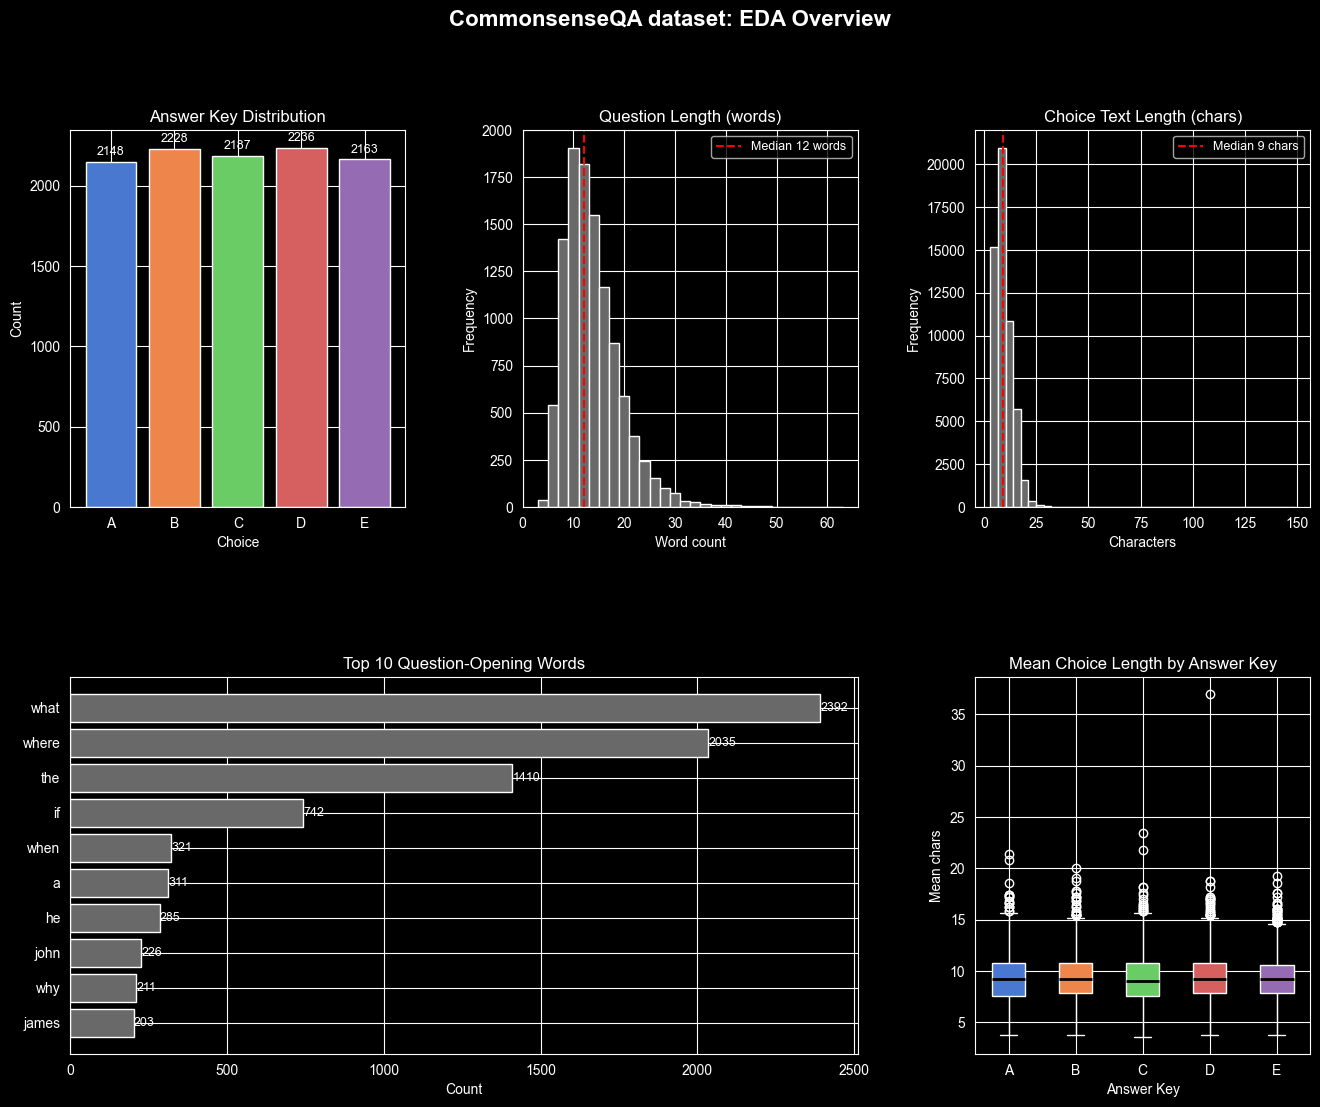

In [9]:
# Set up figure
fig = plt.figure(figsize=(16, 12))
fig.suptitle("CommonsenseQA dataset: EDA Overview", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35) #initialize a 2x3 grid layout for the subplots
 
# Plot A:  Answer key distribution 
ax1 = fig.add_subplot(gs[0, 0])
counts = df_all["answerKey"].value_counts().reindex(order)
bars = ax1.bar(order, counts.values, color=sns.color_palette("muted", len(order)))
ax1.bar_label(bars, padding=3, fontsize=9)
ax1.set_title("Answer Key Distribution")
ax1.set_xlabel("Choice"); ax1.set_ylabel("Count")
 
# Plot B: Question text length histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_all["q_len_words"].dropna(), bins=30, color="dimgrey", edgecolor="white")
ax2.axvline(df_all["q_len_words"].median(), color="red", linestyle="--",
            label=f"Median {df_all['q_len_words'].median():.0f} words")
ax2.set_title("Question Length (words)")
ax2.set_xlabel("Word count"); ax2.set_ylabel("Frequency")
ax2.legend(fontsize=9)
 
# Plot C: Choice text length histogram 
ax3 = fig.add_subplot(gs[0, 2])
choice_lens = [len(t) for t in all_choice_texts]
ax3.hist(choice_lens, bins=40, color="dimgrey", edgecolor="white") 
ax3.axvline(np.median(choice_lens), color="red", linestyle="--",
            label=f"Median {np.median(choice_lens):.0f} chars")
ax3.set_title("Choice Text Length (chars)")
ax3.set_xlabel("Characters"); ax3.set_ylabel("Frequency")
ax3.legend(fontsize=9)
 
# Plot D: Top 10 question-opening words
ax4 = fig.add_subplot(gs[1, 0:2]) #span two columns instead of one 
top_starts = df_all["q_starts_with"].value_counts().head(10)
ax4.barh(top_starts.index[::-1], top_starts.values[::-1], color="dimgrey")
ax4.set_title("Top 10 Question-Opening Words")
ax4.set_xlabel("Count")
for i, v in enumerate(top_starts.values[::-1]):
    ax4.text(v + 0.5, i, str(v), va="center", fontsize=9)
 
# Plot E: Mean choice length by answer key
ax5 = fig.add_subplot(gs[1, 2])
groups = [df_all[df_all["answerKey"] == k]["choice_len_mean"].dropna().values for k in order]
bp = ax5.boxplot(groups, labels=order, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], sns.color_palette("muted", len(order))):
    patch.set_facecolor(color)
ax5.set_title("Mean Choice Length by Answer Key")
ax5.set_xlabel("Answer Key"); ax5.set_ylabel("Mean chars")
 
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
print("\nPlot saved -> eda_overview.png")
plt.show()
 

#### Worked examples 
(to get an intuition of what the model will see)

In [10]:
examples = df_all.sample(3, random_state=42)

for i, row in examples.iterrows():
    print(f"\n--- Example {i} ---")
    print("Question:", row["question"])
    print("Choices:", row["choices_parsed"])
    print("Answer:", row["answerKey"])


--- Example 4985 ---
Question: What kind of place is an excavation site?
Choices: {'A': 'working ground', 'B': 'quarry', 'C': 'desert', 'D': 'work area', 'E': 'under ground'}
Answer: D

--- Example 4710 ---
Question: which half of the earth do marmots live in?
Choices: {'A': 'south', 'B': 'northern hemisphere', 'C': 'north america', 'D': 'vancouver island', 'E': 'jungle'}
Answer: B

--- Example 9414 ---
Question: Shareholders gather in what to have meetings?
Choices: {'A': 'large company', 'B': 'building', 'C': 'den', 'D': 'financial trouble', 'E': 'factory'}
Answer: B


## Model 1: Decoder model GPT-small

In [11]:
# Decoder configuration
decoder_model_name = "openai-community/gpt2"
SEED = 42
SAMPLE_SIZE = 120  # change for testing

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def format_decoder_split(raw_df):
    records = []
    for _, row in raw_df.iterrows():
        choice_map = parse_choices(row["choices"])
        labels = list(choice_map.keys())
        options = list(choice_map.values())
        records.append(
            {
                "question": row["question"],
                "answer_key": row["answerKey"],
                "labels": labels,
                "options": options,
                "choice_map": choice_map,
            }
        )
    return pd.DataFrame(records)

decoder_datasets = {
    "train": format_decoder_split(df),
    "validation": format_decoder_split(df_val),
    "all": format_decoder_split(df_all),
}
for split_name, split_df in decoder_datasets.items():
    print(f"decoder {split_name}: {len(split_df)} examples")


# Decoder model loading
decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_model_name)
if decoder_tokenizer.pad_token is None:
    decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

decoder_model = AutoModelForCausalLM.from_pretrained(decoder_model_name)
decoder_model.to(DEVICE)
decoder_model.eval()

def build_decoder_prompt(question, labels, options):
    options_block = "\n".join(f"{label}. {text}" for label, text in zip(labels, options))
    return f"Question: {question}\n{options_block}\nAnswer:"


def build_decoder_null_prompt(labels, options):
    options_block = "\n".join(f"{label}. {text}" for label, text in zip(labels, options))
    return f"\n{options_block}\nAnswer:"

def calibrated_decoder_option_logps(question_prompt, labels, options):
    option_logps_q = np.array([score_decoder_option_logprob(question_prompt, option) for option in options], dtype=np.float64)
    null_prompt = build_decoder_null_prompt(labels, options)
    option_logps_null = np.array([score_decoder_option_logprob(null_prompt, option) for option in options], dtype=np.float64)
    option_logps_calibrated = option_logps_q - option_logps_null
    return option_logps_calibrated, option_logps_q, option_logps_null

@torch.no_grad()
def score_decoder_option_logprob(prompt, option_text):
    prompt_ids = decoder_tokenizer(prompt, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    target_ids = decoder_tokenizer(" " + option_text, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)

    full_ids = torch.cat([prompt_ids, target_ids], dim=1)
    logits = decoder_model(full_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)

    start = prompt_ids.shape[1]
    total = 0.0
    for pos in range(start, full_ids.shape[1]):
        token_id = full_ids[0, pos]
        total += log_probs[0, pos - 1, token_id].item()
    token_count = max(1, target_ids.shape[1])
    return total / token_count

def predict_decoder_with_confidence(question, labels, options, apply_calibration=True):
    prompt = build_decoder_prompt(question, labels, options)
    option_logps_q = np.array([score_decoder_option_logprob(prompt, option) for option in options], dtype=np.float64)
    option_logps_null = np.zeros_like(option_logps_q)
    option_logps = option_logps_q

    if apply_calibration:
        option_logps, option_logps_q, option_logps_null = calibrated_decoder_option_logps(prompt, labels, options)

    shifted = option_logps - np.max(option_logps)
    probs = np.exp(shifted)
    probs = probs / probs.sum()

    best_idx = int(np.argmax(probs))
    return {
        "pred_label": labels[best_idx],
        "confidence": float(probs[best_idx]),
        "option_probs": {label: float(prob) for label, prob in zip(labels, probs)},
        "option_logprobs": {label: float(lp) for label, lp in zip(labels, option_logps)},
        "option_logprobs_q": {label: float(lp) for label, lp in zip(labels, option_logps_q)},
        "option_logprobs_null": {label: float(lp) for label, lp in zip(labels, option_logps_null)},
    }

def evaluate_decoder_split(decoder_df, sample_size=None):
    run_df = decoder_df.sample(n=sample_size, random_state=SEED).reset_index(drop=True) if sample_size else decoder_df.reset_index(drop=True)
    rows = []
    for _, row in tqdm(run_df.iterrows(), total=len(run_df), desc="Decoder evaluating"):
        result = predict_decoder_with_confidence(row["question"], row["labels"], row["options"])
        correct = result["pred_label"] == row["answer_key"]
        rows.append(
            {
                "question": row["question"],
                "answerKey": row["answer_key"],
                "predicted": result["pred_label"],
                "correct": correct,
                "confidence": result["confidence"],
                "all_probs": result["option_probs"],
                "all_scores": result["option_logprobs"],
            }
        )
    return pd.DataFrame(rows)

def expected_calibration_error(conf, corr, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        mask = (conf >= left) & (conf < right if i < n_bins - 1 else conf <= right)
        if mask.sum() == 0:
            continue
        bin_acc = corr[mask].mean()
        bin_conf = conf[mask].mean()
        ece += (mask.sum() / len(conf)) * abs(bin_acc - bin_conf)
    return float(ece)

def summarize_decoder_results(results):
    accuracy = float(results["correct"].mean())
    avg_conf = float(results["confidence"].mean())
    corr = float(np.corrcoef(results["confidence"], results["correct"])[0, 1]) if len(results) > 1 else float("nan")
    ece = expected_calibration_error(results["confidence"].to_numpy(), results["correct"].to_numpy(), n_bins=10)
    return {
        "n": int(len(results)),
        "accuracy": accuracy,
        "avg_confidence": avg_conf,
        "confidence_correctness_corr": corr,
        "ece": ece,
    }

# test on train + validation split (df_all)
decoder_all_results = evaluate_decoder_split(decoder_datasets["all"], sample_size=None)
decoder_all_metrics = summarize_decoder_results(decoder_all_results)
print(decoder_all_metrics)
decoder_all_results.head(5)

# Save to CSV
decoder_all_results.to_csv("gpt2_results.csv", index=False)

#{'n': 10962, 'accuracy': 0.2835249042145594, 'avg_confidence': 0.4011751724200872, 'confidence_correctness_corr': 0.07472063852530818, 'ece': 0.11765026820552785}

decoder train: 9741 examples
decoder validation: 1221 examples
decoder all: 10962 examples


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Decoder evaluating: 100%|██████████| 10962/10962 [3:34:42<00:00,  1.18s/it] 

{'n': 10962, 'accuracy': 0.2835249042145594, 'avg_confidence': 0.4011751724200872, 'confidence_correctness_corr': 0.07472063852530818, 'ece': 0.11765026820552785}


,question,answer_key,predicted,correct,confidence,all_probs
0,The sanctions against the school were a punish...,A,C,0,0.412300,"{'A': 0.07038572531231893, 'B': 0.100381565044..."
1,Sammy wanted to go to where the people were. ...,B,B,1,0.229389,"{'A': 0.11700572717135416, 'B': 0.229389406608..."
2,To locate a choker not located in a jewelry bo...,A,C,0,0.331416,"{'A': 0.27460799518695683, 'B': 0.041719401927..."
3,Google Maps and other highway and street GPS s...,D,A,0,0.383736,"{'A': 0.38373631782536083, 'B': 0.242927346308..."
4,"The fox walked from the city into the forest, ...",C,D,0,0.344688,"{'A': 0.20361572358092797, 'B': 0.230968846084..."


## Model 2: Encoder model RoBERTa

This is an earlier approach, where I found the "common token bias" as identified by Zhao et al. (the tendency of language models to prefer tokens that are frequent in pre-training data). They show that this causes models to heavily favour certain labels regardless of the question. This corresponds with the A-bias problem observed. Their fix is to estimate the model's bias by feeding a content-free "N/A" input and then calibrating the output distribution to be uniform across answers. That principle is what the null-prompt subtraction later is based on.

In [12]:
# Load the model 
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForMaskedLM.from_pretrained("roberta-base")
model.eval()

# Shared base template (14-20 tokens w/ choices clearly delimited)
prompt_template = ("Question: {question}\n"
    "A) {A}\nB) {B}\nC) {C}\nD) {D}\nE) {E}\n"
    "Answer:")

# Prompt template for zero-shot prompting 
def build_prompt_roberta(question, choices):
    """
    Args:
        question (str): the question string
        choices (dict): {'A': 'text', 'B': 'text', ...}
    Returns:
        str: the full prompt with a <mask> token for RoBERTa to fill
    """
    return prompt_template.format(question=question, **choices) + " <mask>" 

# Define scoring function 
# Encoders (like RoBERTa) don't generate text, so instead we score each
# choice label (A-E) by how likely the model predicts it at the <mask> position.
# -> Confidence score = the softmax probability of each label token? 
def get_label_probabilities(prompt):
    """
    Returns a dict of {label: probability} for A–E at the <mask> position
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    mask_index = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]

    with torch.no_grad():
        outputs = model(**inputs)

    logits_at_mask = outputs.logits[0, mask_index, :]  # shape: (1, vocab_size)

    # Get token IDs for labels A–E (with leading space, as RoBERTa tokenizes " A" not "A")
    label_token_ids = {
        label: tokenizer.convert_tokens_to_ids(f"Ġ{label}")  # Ġ = space prefix in RoBERTa vocab
        for label in ["A", "B", "C", "D", "E"]}

    # Softmax over just the 5 label tokens to get relative confidence
    label_logits = torch.tensor([logits_at_mask[0, tid] for tid in label_token_ids.values()])
    probs = torch.softmax(label_logits, dim=0)

    return {label: probs[i].item() for i, label in enumerate(label_token_ids)}

# Run on 1 row to test out
sample = df_all.iloc[5]

prompt = build_prompt_roberta(sample["question"], sample["choices_parsed"])
probs  = get_label_probabilities(prompt)

predicted = max(probs, key=probs.get)
correct   = sample["answerKey"]

print(f"Question : {sample['question']}")
print(f"Probs : {probs}")
print(f"Predicted: {predicted}, the right answer was: {correct} -> So, answer was {'correct' if predicted == correct else 'wrong'}")

#df_testing = df_all[:870]
# Run on full dataset 

# results = []
# for _, row in tqdm(df_testing.iterrows(), total = len(df_testing)):
#     prompt = build_prompt_roberta(row["question"], row["choices_parsed"])
#     probs  = get_label_probabilities(prompt)
#     predicted = max(probs, key=probs.get)
#     results.append({
#         "question"   : row["question"],
#         "answerKey"  : row["answerKey"],
#         "predicted"  : predicted,
#         "correct"    : predicted == row["answerKey"],
#         "confidence" : max(probs.values()), #confidence = prob of chosen answer
#         "all_probs"  : probs})

# df_results = pd.DataFrame(results)
# print(f"Accuracy: {df_results['correct'].mean():.3f}")
# df_results.to_csv("roberta_results.csv", index=False)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Question : What home entertainment equipment requires cable?
Probs : {'A': 0.48913833498954773, 'B': 0.03222411125898361, 'C': 0.2343917340040207, 'D': 0.07088322937488556, 'E': 0.17336250841617584}
Predicted: A, the right answer was: D -> So, answer was wrong


### Calibrated PLL

In [13]:
# Function to search for the answer token sequence inside the prompt
def find_subsequence(seq, subseq):
    for i in range(len(seq) - len(subseq) + 1):
        if seq[i:i+len(subseq)] == subseq:
            return i
    return -1

# Define pll score
def pll_score(prompt, answer_text):
    # Tokenize full prompt 
    ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    # Tokenize answer 
    ans_ids = tokenizer(" " + answer_text, add_special_tokens=False)["input_ids"]
    L = len(ans_ids)

    ids_list = ids.tolist()

    # Check if this is a question prompt or null prompt
    answer_prefix = tokenizer("Answer:", add_special_tokens=False)["input_ids"]
    prefix_start = find_subsequence(ids_list, answer_prefix)

    if prefix_start != -1:
        # Question prompt 
        search_start = prefix_start + len(answer_prefix)
        start = find_subsequence(ids_list[search_start:], ans_ids)
        if start == -1:
            raise ValueError("Answer tokens not found after 'Answer:'")
        start += search_start

    else:
        # Null prompt
        start = find_subsequence(ids_list, ans_ids)
        if start == -1:
            raise ValueError("Answer tokens not found in null prompt")

    total = 0.0
    # Compute pseudo-log-likelihood by masking each answer token once
    for i in range(start, start + L):
        masked = ids.clone()
        masked[i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = model(masked.unsqueeze(0)).logits[0, i]

        # Log-prob of the true token at this position
        log_probs = torch.log_softmax(logits, dim=-1)
        total += log_probs[ids[i]].item()

    # Length-normalized PLL
    return total / L


def score_calibrated(question, choices):
    scores = {}
    # Build the same options block as GPT-2
    options_block = "\n".join(f"{label}. {text}" for label, text in choices.items())

    for label, text in choices.items():
        # Prompt w/ question (contextual likelihood)
        #prompt_q = f"Question: {question}\nAnswer: {text}"
        prompt_q = f"Question: {question}\n{options_block}\nAnswer: {text}" #matching GPT-2
        # Null prompt -> estimates model's inherent bias toward the answer
        prompt_null = f"<mask> {text}"

        # Compute PLL for both
        score_q = pll_score(prompt_q, text)
        score_null = pll_score(prompt_null, text)

        # Subtract to remove token-frequency bias
        scores[label] = score_q - score_null

    return scores

In [ ]:
#df_testing = df_all[:50]
results = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all)):
    question = row["question"]
    choices  = row["choices_parsed"]

    # Get calibrated PLL scores for each answer option
    scores = score_calibrated(question, choices)

    # Convert scores -> probabilities (softmax)
    labels = list(scores.keys())
    score_tensor = torch.tensor([scores[l] for l in labels])
    probs = torch.softmax(score_tensor, dim=0)

    # Pick the highest-prob answer
    pred_idx = torch.argmax(probs).item()
    predicted = labels[pred_idx]
    confidence = probs[pred_idx].item()

    # Save result
    results.append({
        "question"   : question,
        "answerKey"  : row["answerKey"],
        "predicted"  : predicted,
        "correct"    : predicted == row["answerKey"],
        "confidence" : confidence,
        "all_probs"  : {labels[i]: probs[i].item() for i in range(len(labels))},
        "all_scores" : scores})
    

# Convert to DataFrame
df_encoder_results = pd.DataFrame(results)

print(f"Accuracy (Calibrated PLL): {df_encoder_results['correct'].mean():.3f}")

# Save to CSV
df_encoder_results.to_csv("roberta_calibrated_pll_results_fulldata.csv", index=False)

  
#On 500 rows: 0.264 aaccuracy in 9 minutes 
#On full train: 0.29 in ±3 hrs
#On full dataset (val+train): 0.239 in ±4 hrs 

  5%|▍         | 516/10962 [10:09<2:56:05,  1.01s/it]